# 第一章配套代码：投资组合理论基础

本 notebook 对应 `01_portfolio.md`，依次生成讲义中引用的所有图表。

**运行前请确认**：
- 已安装：`baostock`, `pandas`, `numpy`, `scipy`, `statsmodels`, `matplotlib`
- 已在项目根目录下执行（即 `01_portfolio.md` 所在目录）
- `data/stock/` 目录下已有股票 CSV 数据（运行第0节下载）

## 第0节　环境设置与数据下载

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------
# 中文字体设置（根据系统选择合适字体）
# ------------------------------------------------------------------
import matplotlib
import platform

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Microsoft YaHei')
elif platform.system() == 'Darwin':  # macOS
    matplotlib.rc('font', family='PingFang SC')
else:  # Linux
    matplotlib.rc('font', family='WenQuanYi Micro Hei')

matplotlib.rcParams['axes.unicode_minus'] = False  # 负号正常显示
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 150
matplotlib.rcParams['savefig.bbox'] = 'tight'

# ------------------------------------------------------------------
# 创建必要目录
# ------------------------------------------------------------------
os.makedirs('data/stock', exist_ok=True)
os.makedirs('figs', exist_ok=True)

print('环境设置完毕')

环境设置完毕


In [2]:
import baostock as bs

# ------------------------------------------------------------------
# 登录 baostock
# ------------------------------------------------------------------
lg = bs.login()
print('登录状态:', lg.error_msg)

start_date = '2020-01-01'
end_date   = datetime.today().strftime('%Y-%m-%d')

# ------------------------------------------------------------------
# 股票列表：3 支个股 + 沪深300指数
# ------------------------------------------------------------------
stocks = {
    '600036': {'bs_code': 'sh.600036', 'name': '招商银行',  'industry': '银行'},
    '601633': {'bs_code': 'sh.601633', 'name': '长城汽车',  'industry': '汽车'},
    '000063': {'bs_code': 'sz.000063', 'name': '中兴通讯',  'industry': '通讯'},
}
index_code = 'sh.000300'  # 沪深300，用作市场基准

# ------------------------------------------------------------------
# 下载个股日线数据（后复权）
# ------------------------------------------------------------------
for code, info in stocks.items():
    save_path = f"data/stock/stock_{code}.csv"
    if os.path.exists(save_path):
        print(f'{code} {info["name"]}：数据已存在，跳过下载')
        continue

    print(f'下载 {code} {info["name"]} ...')
    rs = bs.query_history_k_data_plus(
        info['bs_code'],
        'date,code,open,high,low,close,volume,amount',
        start_date=start_date, end_date=end_date,
        frequency='d', adjustflag='3'  # 后复权
    )
    rows = []
    while rs.error_code == '0' and rs.next():
        rows.append(rs.get_row_data())
    df = pd.DataFrame(rows, columns=rs.fields)
    for col in ['open','high','low','close','volume','amount']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.rename(columns={'date':'日期','code':'股票代码','open':'开盘价',
                       'close':'收盘价','high':'最高价','low':'最低价',
                       'volume':'成交量','amount':'成交额'}, inplace=True)
    df.to_csv(save_path, index=False, encoding='utf-8-sig')
    print(f'  已保存 {save_path}，共 {len(df)} 行')

# ------------------------------------------------------------------
# 下载沪深300指数日线数据
# ------------------------------------------------------------------
idx_path = 'data/stock/index_000300.csv'
if not os.path.exists(idx_path):
    print('下载沪深300指数 ...')
    rs = bs.query_history_k_data_plus(
        index_code, 'date,code,close',
        start_date=start_date, end_date=end_date, frequency='d'
    )
    rows = []
    while rs.error_code == '0' and rs.next():
        rows.append(rs.get_row_data())
    df_idx = pd.DataFrame(rows, columns=rs.fields)
    df_idx['close'] = pd.to_numeric(df_idx['close'], errors='coerce')
    df_idx.rename(columns={'date':'日期','close':'收盘价'}, inplace=True)
    df_idx.to_csv(idx_path, index=False, encoding='utf-8-sig')
    print(f'  已保存 {idx_path}')
else:
    print('沪深300数据已存在，跳过下载')

bs.logout()
print('数据下载完毕')

login success!
登录状态: success
下载 600036 招商银行 ...
  已保存 data/stock/stock_600036.csv，共 1515 行
下载 601633 长城汽车 ...
  已保存 data/stock/stock_601633.csv，共 1515 行
下载 000063 中兴通讯 ...
  已保存 data/stock/stock_000063.csv，共 1515 行
下载沪深300指数 ...
  已保存 data/stock/index_000300.csv
logout success!
数据下载完毕


## 第1节　收益与风险的度量

生成图：`fig_portfolio_01_returns.png`

In [3]:
# ------------------------------------------------------------------
# 1. 读取数据，计算日对数收益率
# ------------------------------------------------------------------
stock_info = {
    '600036': '招商银行',
    '601633': '长城汽车',
    '000063': '中兴通讯',
}

price_dict = {}  # 存储各股票收盘价
ret_dict   = {}  # 存储各股票日对数收益率

for code, name in stock_info.items():
    df = pd.read_csv(f'data/stock/stock_{code}.csv', parse_dates=['日期'])
    df = df.set_index('日期').sort_index()
    df = df[df['收盘价'] > 0].copy()  # 剔除停牌等异常值

    # 对数收益率 = ln(P_t / P_{t-1})
    df['log_ret'] = np.log(df['收盘价'] / df['收盘价'].shift(1))
    price_dict[name] = df['收盘价']
    ret_dict[name]   = df['log_ret'].dropna()

# 将所有收益率对齐为同一时间轴（取交集日期）
ret_df = pd.DataFrame(ret_dict).dropna()
print(f'有效交易日数量：{len(ret_df)}')
print(f'时间范围：{ret_df.index[0].date()} 至 {ret_df.index[-1].date()}')

有效交易日数量：1514
时间范围：2020-01-03 至 2026-04-07


In [4]:
# ------------------------------------------------------------------
# 2. 计算年化统计量
# ------------------------------------------------------------------
TRADING_DAYS = 252  # A 股年化因子
RF_ANNUAL    = 0.02  # 无风险利率（年化 2%）
RF_DAILY     = RF_ANNUAL / TRADING_DAYS

stats = {}
for col in ret_df.columns:
    r = ret_df[col]
    annual_ret = r.mean() * TRADING_DAYS          # 年化期望收益率
    annual_std = r.std()  * np.sqrt(TRADING_DAYS)  # 年化标准差
    stats[col] = {
        '年化期望收益率': f'{annual_ret*100:.2f}%',
        '年化标准差':     f'{annual_std*100:.2f}%',
        '偏度':           f'{r.skew():.3f}',
        '峰度':           f'{r.kurtosis():.3f}',  # 超额峰度（正态为0）
    }

stats_df = pd.DataFrame(stats).T
print('\n=== 年化统计量汇总 ===')
print(stats_df.to_string())


=== 年化统计量汇总 ===
     年化期望收益率   年化标准差     偏度     峰度
招商银行   0.05%  28.13%  0.189  3.128
长城汽车  13.51%  45.23%  0.452  2.116
中兴通讯  -1.53%  42.62%  0.312  2.478


In [5]:
# ------------------------------------------------------------------
# 3. 协方差矩阵（年化）与相关系数矩阵
# ------------------------------------------------------------------
cov_matrix  = ret_df.cov() * TRADING_DAYS   # 日协方差矩阵 × 252 = 年化
corr_matrix = ret_df.corr()

print('\n=== 年化协方差矩阵 ===')
print(cov_matrix.round(4).to_string())

print('\n=== 相关系数矩阵 ===')
print(corr_matrix.round(4).to_string())


=== 年化协方差矩阵 ===
        招商银行    长城汽车    中兴通讯
招商银行  0.0791  0.0280  0.0240
长城汽车  0.0280  0.2045  0.0550
中兴通讯  0.0240  0.0550  0.1816

=== 相关系数矩阵 ===
        招商银行    长城汽车    中兴通讯
招商银行  1.0000  0.2203  0.2002
长城汽车  0.2203  1.0000  0.2853
中兴通讯  0.2002  0.2853  1.0000


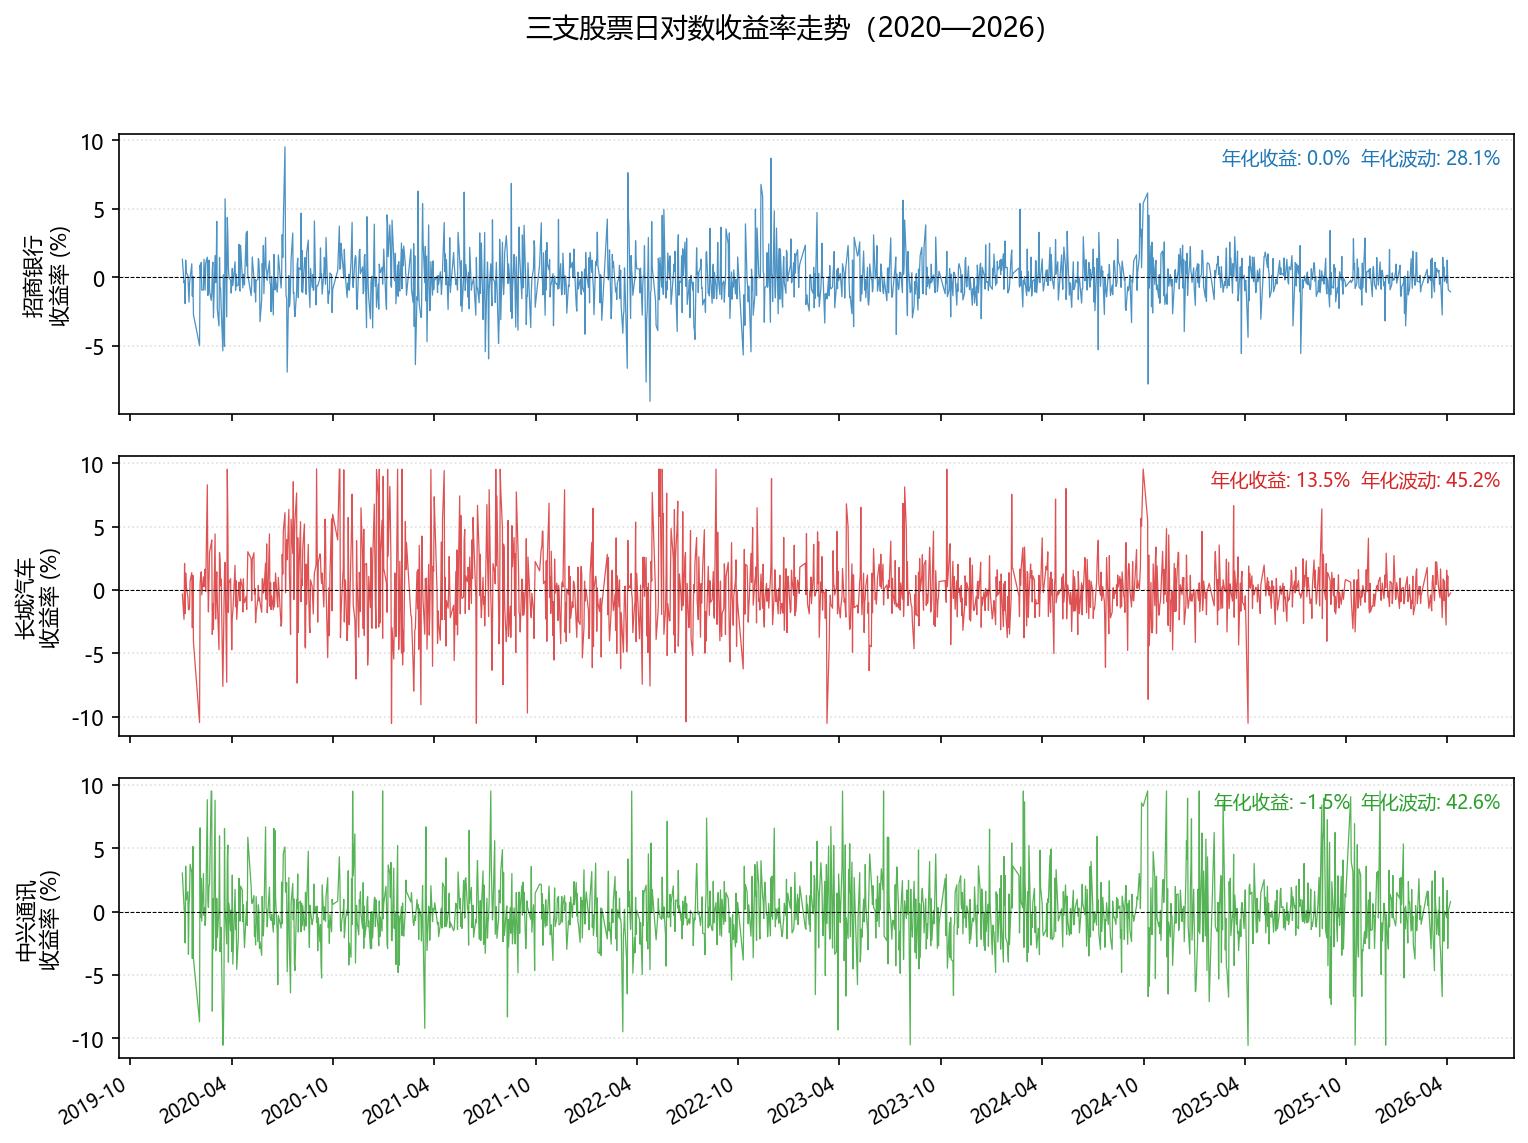

图片已保存：./figs/fig_portfolio_01_returns.png


In [7]:
# ------------------------------------------------------------------
# 4. 绘图：三支股票日对数收益率时序图
#    保存为 ./figs/fig_portfolio_01_returns.png
# ------------------------------------------------------------------
colors = ['#1f77b4', '#d62728', '#2ca02c']  # 蓝、红、绿

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.subplots_adjust(hspace=0.15)

for ax, (name, color) in zip(axes, zip(ret_df.columns, colors)):
    r = ret_df[name]
    ax.plot(r.index, r * 100, color=color, linewidth=0.6, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

    # 年化统计量标注在图内右上角
    mu  = r.mean() * TRADING_DAYS * 100
    std = r.std()  * np.sqrt(TRADING_DAYS) * 100
    ax.text(0.99, 0.95,
            f'年化收益: {mu:.1f}%  年化波动: {std:.1f}%',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color=color)
    ax.set_ylabel(f'{name}\n收益率 (%)', fontsize=10)
    ax.grid(axis='y', linestyle=':', alpha=0.4)

# x 轴格式
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right', fontsize=9)

fig.suptitle('三支股票日对数收益率走势（2020—2026）', fontsize=13, y=0.98)
plt.savefig('./figs/fig_portfolio_01_returns.png')
plt.show()
print('图片已保存：./figs/fig_portfolio_01_returns.png')

## 第2节　分散化的数学本质

生成图：`fig_portfolio_02_diversification.png`、`fig_portfolio_03_n_assets.png`

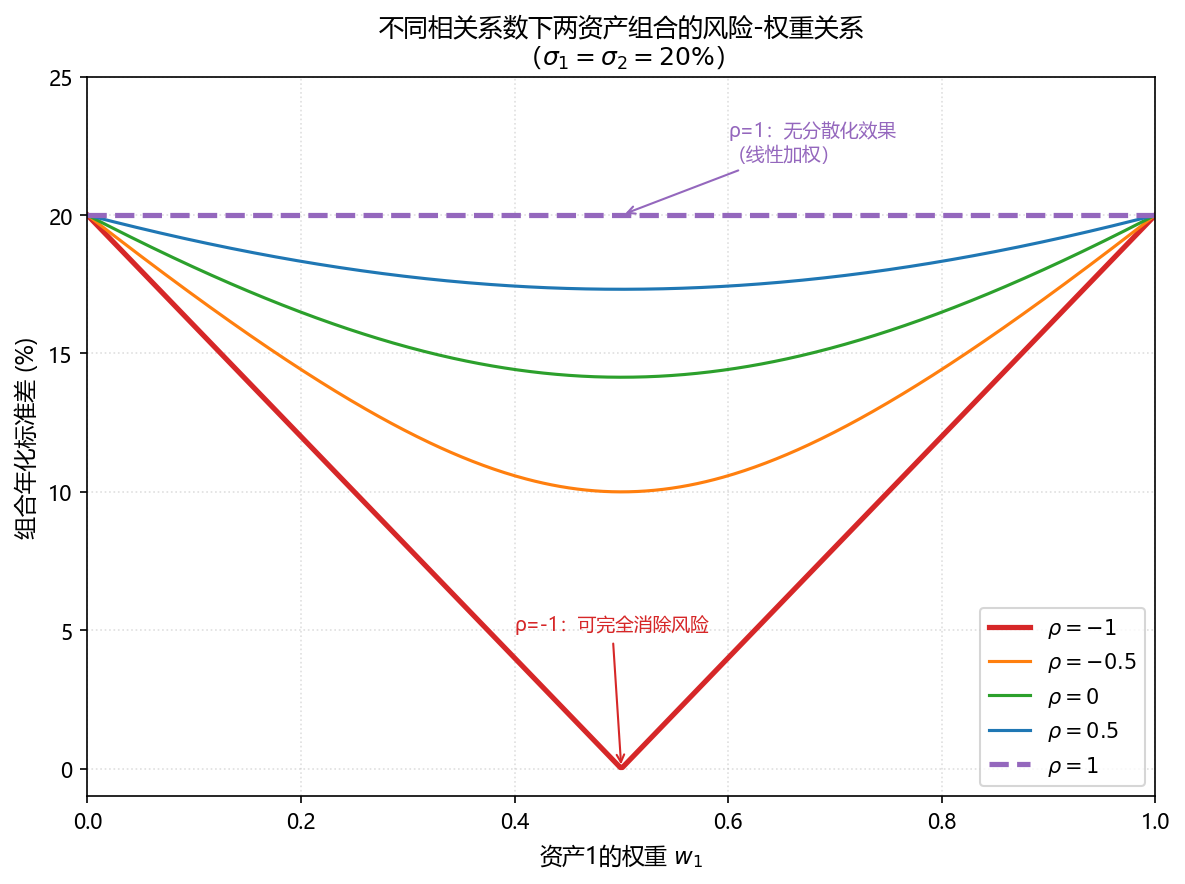

图片已保存：./figs/fig_portfolio_02_diversification.png


In [15]:
# ------------------------------------------------------------------
# 图2：不同相关系数下，两资产组合的风险-权重关系
#       fig_portfolio_02_diversification.png
# ------------------------------------------------------------------
sigma1 = 0.20  # 资产1年化标准差
sigma2 = 0.20  # 资产2年化标准差（对称，便于观察相关性效果）
weights = np.linspace(0, 1, 500)  # 资产1的权重，从0到1
rhos    = [-1.0, -0.5, 0.0, 0.5, 1.0]
colors  = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
labels  = [r'$\rho = -1$', r'$\rho = -0.5$', r'$\rho = 0$',
           r'$\rho = 0.5$', r'$\rho = 1$']

fig, ax = plt.subplots(figsize=(8, 6))

for rho, color, label in zip(rhos, colors, labels):
    # 两资产组合方差公式
    var_p = (weights**2 * sigma1**2
             + (1 - weights)**2 * sigma2**2
             + 2 * weights * (1 - weights) * rho * sigma1 * sigma2)
    std_p = np.sqrt(var_p) * 100  # 转为百分比
    lw = 2.5 if rho in [-1, 1] else 1.5
    ls = '--' if rho == 1 else '-'
    ax.plot(weights, std_p, color=color, lw=lw, ls=ls, label=label)

# 标注 ρ=1 时无分散化效益
ax.annotate('ρ=1：无分散化效果\n（线性加权）',
            xy=(0.5, 20), xytext=(0.6, 22),
            arrowprops=dict(arrowstyle='->', color='#9467bd'),
            fontsize=9, color='#9467bd')

# 标注 ρ=-1 时最大分散化
ax.annotate('ρ=-1：可完全消除风险',
            xy=(0.5, 0), xytext=(0.4, 5),
            arrowprops=dict(arrowstyle='->', color='#d62728'),
            fontsize=9, color='#d62728')

ax.set_xlabel('资产1的权重 $w_1$', fontsize=11)
ax.set_ylabel('组合年化标准差 (%)', fontsize=11)
ax.set_title('不同相关系数下两资产组合的风险-权重关系\n（$\\sigma_1 = \\sigma_2 = 20\\%$）', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(-1, 25)
ax.grid(linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('./figs/fig_portfolio_02_diversification.png')
plt.show()
print('图片已保存：./figs/fig_portfolio_02_diversification.png')

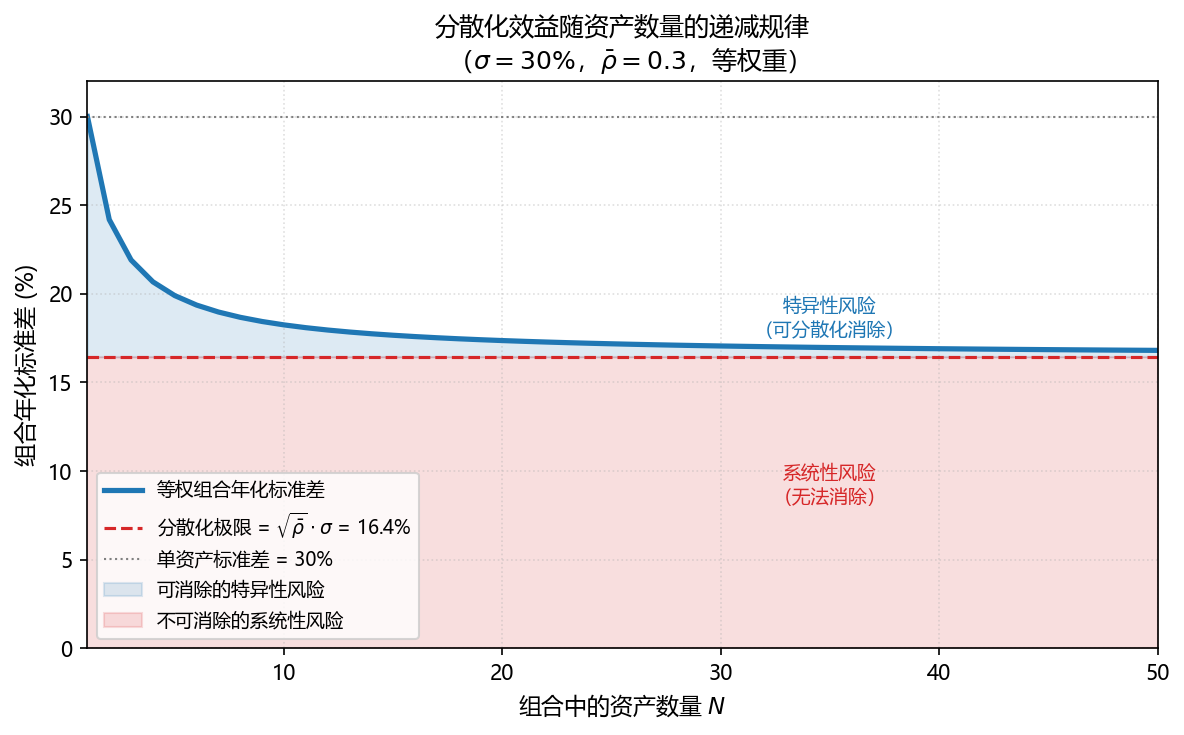

图片已保存：./figs/fig_portfolio_03_n_assets.png


In [17]:
# ------------------------------------------------------------------
# 图3：分散化效益随资产数量的递减规律
#       fig_portfolio_03_n_assets.png
# ------------------------------------------------------------------
sigma_single = 0.30   # 每支股票年化标准差
rho_avg      = 0.30   # 任意两股票间的平均相关系数

n_range = np.arange(1, 51)

# 等权组合方差理论公式：σ²[(1-ρ)/N + ρ]
var_p_theory = sigma_single**2 * ((1 - rho_avg) / n_range + rho_avg)
std_p_theory = np.sqrt(var_p_theory) * 100

# 分散化极限（N → ∞）
limit = np.sqrt(rho_avg) * sigma_single * 100

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(n_range, std_p_theory, color='#1f77b4', lw=2.5, label='等权组合年化标准差')
ax.axhline(limit, color='#d62728', lw=1.5, ls='--',
           label=f'分散化极限 = $\\sqrt{{\\bar{{\\rho}}}}\\cdot\\sigma$ = {limit:.1f}%')
ax.axhline(sigma_single * 100, color='gray', lw=1, ls=':',
           label=f'单资产标准差 = {sigma_single*100:.0f}%')

# 填充两个风险区域
ax.fill_between(n_range, std_p_theory, limit,
                alpha=0.15, color='#1f77b4', label='可消除的特异性风险')
ax.fill_between(n_range, limit, 0,
                alpha=0.15, color='#d62728', label='不可消除的系统性风险')

# 标注文字
ax.text(35, (std_p_theory[-1] + limit) / 2 + 1,
        '特异性风险\n（可分散化消除）', fontsize=9, color='#1f77b4', ha='center')
ax.text(35, limit / 2,
        '系统性风险\n（无法消除）', fontsize=9, color='#d62728', ha='center')

ax.set_xlabel('组合中的资产数量 $N$', fontsize=11)
ax.set_ylabel('组合年化标准差 (%)', fontsize=11)
ax.set_title('分散化效益随资产数量的递减规律\n（$\\sigma=30\\%$，$\\bar{\\rho}=0.3$，等权重）', fontsize=12)
ax.legend(fontsize=9, loc='lower left')
ax.set_xlim(1, 50)
ax.set_ylim(0, 32)
ax.grid(linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('./figs/fig_portfolio_03_n_assets.png')
plt.show()
print('图片已保存：./figs/fig_portfolio_03_n_assets.png')

## 第3节　均值-方差框架与有效前沿

生成图：`fig_portfolio_04_frontier.png`

In [18]:
from scipy.optimize import minimize

# ------------------------------------------------------------------
# 输入数据：使用真实估计值
# ------------------------------------------------------------------
mu    = ret_df.mean().values * TRADING_DAYS           # 年化期望收益率向量
Sigma = ret_df.cov().values  * TRADING_DAYS           # 年化协方差矩阵
names = list(ret_df.columns)
N     = len(mu)

print('年化期望收益率：', dict(zip(names, np.round(mu * 100, 2))))
print('\n年化协方差矩阵：')
print(pd.DataFrame(Sigma, index=names, columns=names).round(4))

# ------------------------------------------------------------------
# 辅助函数：给定权重计算组合均值和标准差
# ------------------------------------------------------------------
def portfolio_perf(w, mu, Sigma):
    ret = w @ mu
    std = np.sqrt(w @ Sigma @ w)
    return ret, std

# ------------------------------------------------------------------
# 蒙特卡洛模拟：随机生成 8000 个组合
# 权重范围允许轻微卖空 [-0.2, 1.2]，以展示完整可行集形状
# ------------------------------------------------------------------
np.random.seed(42)
n_sim = 8000
sim_rets, sim_stds = [], []

for _ in range(n_sim):
    w = np.random.uniform(-0.2, 1.2, N)
    w = w / w.sum()  # 归一化，满足 sum=1
    r, s = portfolio_perf(w, mu, Sigma)
    sim_rets.append(r)
    sim_stds.append(s)

sim_rets = np.array(sim_rets) * 100
sim_stds = np.array(sim_stds) * 100

年化期望收益率： {'招商银行': np.float64(0.05), '长城汽车': np.float64(13.51), '中兴通讯': np.float64(-1.53)}

年化协方差矩阵：
        招商银行    长城汽车    中兴通讯
招商银行  0.0791  0.0280  0.0240
长城汽车  0.0280  0.2045  0.0550
中兴通讯  0.0240  0.0550  0.1816


In [19]:
# ------------------------------------------------------------------
# 数值优化：求最小方差边界
# 在不同目标收益率水平下，求最小化方差的权重
# ------------------------------------------------------------------
def min_variance(target_ret, mu, Sigma):
    """给定目标收益率，求最小方差组合（允许轻微卖空）"""
    N = len(mu)
    constraints = [
        {'type': 'eq', 'fun': lambda w: w @ mu - target_ret},   # 目标收益约束
        {'type': 'eq', 'fun': lambda w: w.sum() - 1},            # 全投资约束
    ]
    bounds = [(-0.3, 1.3)] * N  # 允许适度卖空
    w0 = np.ones(N) / N
    res = minimize(lambda w: w @ Sigma @ w, w0,
                   method='SLSQP', bounds=bounds, constraints=constraints)
    return res

# 扫描目标收益率区间（覆盖单资产收益率的范围）
target_range = np.linspace(mu.min(), mu.max(), 60)
frontier_stds, frontier_rets = [], []

for target in target_range:
    res = min_variance(target, mu, Sigma)
    if res.success:
        _, std = portfolio_perf(res.x, mu, Sigma)
        frontier_stds.append(std * 100)
        frontier_rets.append(target * 100)

frontier_stds = np.array(frontier_stds)
frontier_rets = np.array(frontier_rets)

# 全局最小方差组合（GMVP）
gmvp_idx = np.argmin(frontier_stds)
gmvp_std = frontier_stds[gmvp_idx]
gmvp_ret = frontier_rets[gmvp_idx]
print(f'GMVP：年化收益率 {gmvp_ret:.2f}%，年化标准差 {gmvp_std:.2f}%')

GMVP：年化收益率 1.78%，年化标准差 24.56%


In [20]:
# ------------------------------------------------------------------
# 资本市场线（CML）：从无风险资产切到有效前沿
# 切点 = 最大夏普比率组合
# ------------------------------------------------------------------
RF = RF_ANNUAL * 100  # 无风险利率（百分比，2%）

def neg_sharpe(w, mu, Sigma, rf):
    """最大化夏普比率 <=> 最小化负夏普比率"""
    r, s = portfolio_perf(w, mu, Sigma)
    return -(r - rf) / s if s > 1e-8 else 0

constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
bounds = [(-0.3, 1.3)] * N
res_msr = minimize(neg_sharpe, np.ones(N)/N,
                   args=(mu, Sigma, RF_ANNUAL),
                   method='SLSQP', bounds=bounds, constraints=constraints)

msr_ret, msr_std = portfolio_perf(res_msr.x, mu, Sigma)
msr_ret_pct = msr_ret * 100
msr_std_pct = msr_std * 100
print(f'最大夏普比率组合（切点/市场组合）：')
print(f'  年化收益率 {msr_ret_pct:.2f}%，年化标准差 {msr_std_pct:.2f}%')
print(f'  夏普比率 {(msr_ret_pct - RF) / msr_std_pct:.3f}')
print(f'  权重：{dict(zip(names, np.round(res_msr.x, 3)))}')

# CML：从 (0, RF) 到 (msr_std_pct, msr_ret_pct) 的延长线
cml_std = np.array([0, msr_std_pct * 1.6])
cml_ret = RF + (msr_ret_pct - RF) / msr_std_pct * cml_std

最大夏普比率组合（切点/市场组合）：
  年化收益率 18.02%，年化标准差 56.49%
  夏普比率 0.284
  权重：{'招商银行': np.float64(0.0), '长城汽车': np.float64(1.3), '中兴通讯': np.float64(-0.3)}


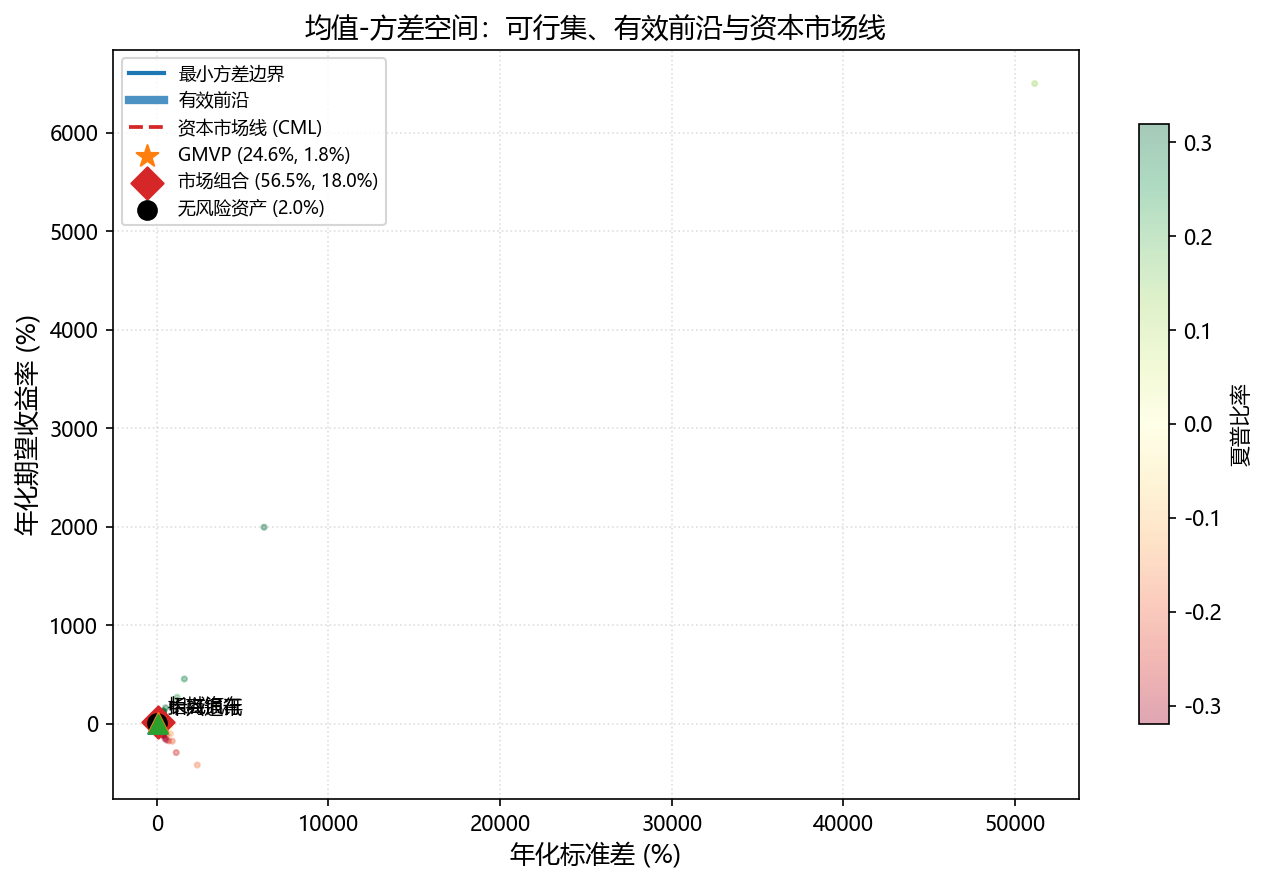

图片已保存：./figs/fig_portfolio_04_frontier.png


In [21]:
# ------------------------------------------------------------------
# 绘图：均值-方差空间可行集 + 有效前沿 + CML
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

# 蒙特卡洛可行集散点（按夏普比率着色）
sharpe_sim = (sim_rets - RF) / sim_stds
sc = ax.scatter(sim_stds, sim_rets, c=sharpe_sim, cmap='RdYlGn',
                alpha=0.35, s=6, zorder=1)
plt.colorbar(sc, ax=ax, label='夏普比率', shrink=0.8)

# 最小方差边界（完整）
ax.plot(frontier_stds, frontier_rets, color='#1f77b4', lw=2, zorder=3,
        label='最小方差边界')

# 有效前沿（GMVP 以上部分，加粗）
eff_mask = frontier_rets >= gmvp_ret
ax.plot(frontier_stds[eff_mask], frontier_rets[eff_mask],
        color='#1f77b4', lw=4, zorder=4, alpha=0.8, label='有效前沿')

# 资本市场线
ax.plot(cml_std, cml_ret, color='#d62728', lw=1.8, ls='--',
        zorder=5, label='资本市场线 (CML)')

# 标注关键点
ax.scatter(gmvp_std, gmvp_ret, color='#ff7f0e', s=120,
           zorder=6, marker='*', label=f'GMVP ({gmvp_std:.1f}%, {gmvp_ret:.1f}%)')
ax.scatter(msr_std_pct, msr_ret_pct, color='#d62728', s=120,
           zorder=6, marker='D', label=f'市场组合 ({msr_std_pct:.1f}%, {msr_ret_pct:.1f}%)')
ax.scatter(0, RF, color='black', s=80, zorder=6, marker='o', label=f'无风险资产 ({RF:.1f}%)')

# 标注三支个股位置
stock_stds = np.sqrt(np.diag(Sigma)) * 100
stock_rets = mu * 100
for name, s, r in zip(names, stock_stds, stock_rets):
    ax.scatter(s, r, s=80, zorder=6, marker='^')
    ax.annotate(name, (s, r), textcoords='offset points',
                xytext=(5, 5), fontsize=9)

ax.set_xlabel('年化标准差 (%)', fontsize=12)
ax.set_ylabel('年化期望收益率 (%)', fontsize=12)
ax.set_title('均值-方差空间：可行集、有效前沿与资本市场线', fontsize=13)
ax.legend(fontsize=8.5, loc='upper left')
ax.grid(linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('./figs/fig_portfolio_04_frontier.png')
plt.show()
print('图片已保存：./figs/fig_portfolio_04_frontier.png')

## 第4节　CAPM 与证券市场线

生成图：`fig_portfolio_05_sml.png`

In [22]:
import statsmodels.api as sm

# ------------------------------------------------------------------
# 读取沪深300指数，计算日对数收益率
# ------------------------------------------------------------------
df_idx = pd.read_csv('data/stock/index_000300.csv', parse_dates=['日期'])
df_idx = df_idx.set_index('日期').sort_index()
df_idx = df_idx[df_idx['收盘价'] > 0]
df_idx['mkt_ret'] = np.log(df_idx['收盘价'] / df_idx['收盘价'].shift(1))
mkt_ret = df_idx['mkt_ret'].dropna()

# 对齐日期
common_dates = ret_df.index.intersection(mkt_ret.index)
ret_aligned  = ret_df.loc[common_dates]
mkt_aligned  = mkt_ret.loc[common_dates]

print(f'对齐后有效交易日：{len(common_dates)} 天')

# ------------------------------------------------------------------
# CAPM 回归：对每支股票，以日超额收益率回归市场超额收益率
# R_i - Rf = α + β (R_m - Rf) + ε
# ------------------------------------------------------------------
rf_daily = RF_DAILY
mkt_excess = mkt_aligned - rf_daily  # 市场超额收益率（自变量）
X = sm.add_constant(mkt_excess)       # 加截距项

capm_results = {}
print('\n=== CAPM 回归结果 ===')

for name in names:
    y = ret_aligned[name] - rf_daily  # 个股超额收益率
    model = sm.OLS(y, X).fit()
    alpha = model.params.iloc[0]  # 截距 α（日度）
    beta  = model.params.iloc[1]  # β
    r2    = model.rsquared
    t_alpha = model.tvalues.iloc[0]
    t_beta  = model.tvalues.iloc[1]

    capm_results[name] = {
        'α (年化%)': alpha * TRADING_DAYS * 100,
        't(α)':      round(t_alpha, 3),
        'β':         round(beta, 4),
        't(β)':      round(t_beta, 3),
        'R²':        round(r2, 4),
    }
    print(f'\n{name}')
    print(f'  α = {alpha*TRADING_DAYS*100:.2f}% (年化)，t = {t_alpha:.2f}')
    print(f'  β = {beta:.4f}，t = {t_beta:.2f}')
    print(f'  R² = {r2:.4f}')

capm_df = pd.DataFrame(capm_results).T
print('\n=== 汇总表 ===')
print(capm_df.to_string())

对齐后有效交易日：1514 天

=== CAPM 回归结果 ===

招商银行
  α = -1.16% (年化)，t = -0.13
  β = 0.9043，t = 29.59
  R² = 0.3667

长城汽车
  α = 12.55% (年化)，t = 0.78
  β = 1.1841，t = 22.05
  R² = 0.2433

中兴通讯
  α = -2.43% (年化)，t = -0.17
  β = 1.2435，t = 25.59
  R² = 0.3022

=== 汇总表 ===
        α (年化%)   t(α)       β    t(β)      R²
招商银行  -1.155038 -0.126  0.9043  29.592  0.3667
长城汽车  12.550501  0.782  1.1841  22.049  0.2433
中兴通讯  -2.431041 -0.167  1.2435  25.588  0.3022


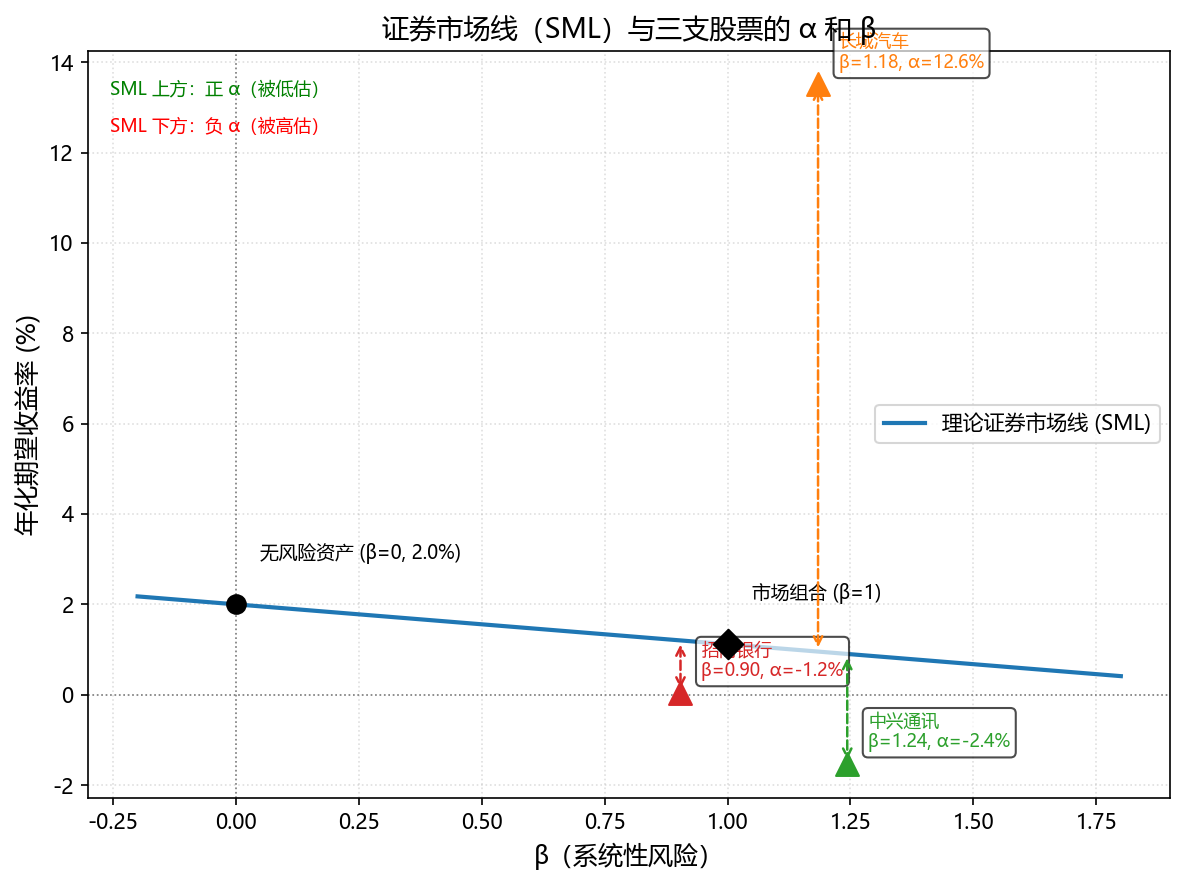

图片已保存：./figs/fig_portfolio_05_sml.png


In [23]:
# ------------------------------------------------------------------
# 绘图：证券市场线（SML）
#       横轴 β，纵轴年化期望收益率
# ------------------------------------------------------------------
# 市场年化期望收益率
mkt_annual_ret = mkt_aligned.mean() * TRADING_DAYS * 100

# SML 理论线：E(Ri) = Rf + β × (E(Rm) - Rf)
beta_range = np.linspace(-0.2, 1.8, 200)
sml_rets   = RF + beta_range * (mkt_annual_ret - RF)

fig, ax = plt.subplots(figsize=(8, 6))

# SML 理论线
ax.plot(beta_range, sml_rets, color='#1f77b4', lw=2, label='理论证券市场线 (SML)')

# 标注市场组合和无风险资产
ax.scatter(1.0, mkt_annual_ret, color='black', s=100, zorder=5, marker='D')
ax.annotate('市场组合 (β=1)', (1.0, mkt_annual_ret),
            xytext=(1.05, mkt_annual_ret + 1), fontsize=9)
ax.scatter(0.0, RF, color='black', s=80, zorder=5, marker='o')
ax.annotate(f'无风险资产 (β=0, {RF:.1f}%)', (0, RF),
            xytext=(0.05, RF + 1), fontsize=9)

# 标注三支个股
plot_colors = ['#d62728', '#ff7f0e', '#2ca02c']
for (name, row), color in zip(capm_df.iterrows(), plot_colors):
    beta_i = row['β']
    # 实际年化期望收益率（样本均值 × 252）
    actual_ret = ret_aligned[name].mean() * TRADING_DAYS * 100
    # SML 预测收益率
    pred_ret   = RF + beta_i * (mkt_annual_ret - RF)
    alpha_i    = row['α (年化%)']

    ax.scatter(beta_i, actual_ret, color=color, s=120, zorder=6, marker='^')
    ax.annotate(
        f'{name}\nβ={beta_i:.2f}, α={alpha_i:.1f}%',
        (beta_i, actual_ret),
        xytext=(10, 8), textcoords='offset points',
        fontsize=8.5, color=color,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )
    # 标注 α（竖向虚线，实际位置 vs SML 预测位置）
    ax.annotate('', (beta_i, actual_ret), (beta_i, pred_ret),
                arrowprops=dict(arrowstyle='<->', color=color, lw=1.2, linestyle='dashed'))

# 参考线
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.axvline(0, color='gray', lw=0.8, ls=':')

ax.set_xlabel('β（系统性风险）', fontsize=12)
ax.set_ylabel('年化期望收益率 (%)', fontsize=12)
ax.set_title('证券市场线（SML）与三支股票的 α 和 β', fontsize=13)
ax.legend(fontsize=10)
ax.grid(linestyle=':', alpha=0.4)

# 添加 α 正负区域说明
ax.text(0.02, 0.96, 'SML 上方：正 α（被低估）',
        transform=ax.transAxes, fontsize=8.5, color='green',
        va='top', style='italic')
ax.text(0.02, 0.91, 'SML 下方：负 α（被高估）',
        transform=ax.transAxes, fontsize=8.5, color='red',
        va='top', style='italic')

plt.tight_layout()
plt.savefig('./figs/fig_portfolio_05_sml.png')
plt.show()
print('图片已保存：./figs/fig_portfolio_05_sml.png')

## 第5节　风险度量进阶

生成图：`fig_portfolio_06_drawdown.png`

In [24]:
# ------------------------------------------------------------------
# 计算完整风险指标体系
# ------------------------------------------------------------------
CONF_LEVEL = 0.95  # VaR / CVaR 置信水平

def max_drawdown(cum_ret_series):
    """计算最大回撤及其峰值/谷值日期"""
    peak = cum_ret_series.cummax()
    drawdown = (cum_ret_series - peak) / peak
    mdd = drawdown.min()
    trough_date = drawdown.idxmin()
    peak_date   = cum_ret_series[:trough_date].idxmax()
    return mdd, peak_date, trough_date, drawdown

risk_stats = {}

for name in names:
    r = ret_aligned[name]  # 日对数收益率

    # 年化基础指标
    annual_ret = r.mean() * TRADING_DAYS
    annual_std = r.std()  * np.sqrt(TRADING_DAYS)

    # 累计净值（以1为起点）
    cum_nav = (1 + r).cumprod()
    # 注：对数收益率转净值时应用 exp，但用简单累积近似也可
    cum_nav = np.exp(r.cumsum())  # 更精确

    # 最大回撤
    mdd, peak_d, trough_d, drawdown_ts = max_drawdown(cum_nav)

    # 历史模拟法 VaR（取 5% 分位数的损失）
    var_95  = -np.percentile(r, (1 - CONF_LEVEL) * 100)

    # CVaR：超过 VaR 阈值的部分的均值
    cvar_95 = -r[r < -var_95].mean()

    # 夏普比率（年化）
    sharpe = (annual_ret - RF_ANNUAL) / annual_std

    # 索提诺比率（下行标准差）
    downside_ret = r[r < RF_DAILY]  # 低于日度无风险利率的收益
    downside_std = np.sqrt((downside_ret - RF_DAILY)**2).mean() * np.sqrt(TRADING_DAYS) if len(downside_ret) > 0 else np.nan
    sortino = (annual_ret - RF_ANNUAL) / downside_std if downside_std > 0 else np.nan

    risk_stats[name] = {
        '年化收益率 (%)':    round(annual_ret * 100, 2),
        '年化标准差 (%)':    round(annual_std * 100, 2),
        '最大回撤 (%)':      round(mdd * 100, 2),
        '回撤峰值日':        str(peak_d.date()),
        '回撤谷值日':        str(trough_d.date()),
        f'日VaR {CONF_LEVEL*100:.0f}% (%)': round(var_95 * 100, 3),
        f'日CVaR {CONF_LEVEL*100:.0f}% (%)':round(cvar_95 * 100, 3),
        '夏普比率':          round(sharpe, 3),
        '索提诺比率':        round(sortino, 3),
    }

risk_df = pd.DataFrame(risk_stats).T
print('=== 完整风险指标体系 ===')
print(risk_df.to_string())

=== 完整风险指标体系 ===
     年化收益率 (%) 年化标准差 (%) 最大回撤 (%)       回撤峰值日       回撤谷值日 日VaR 95% (%) 日CVaR 95% (%)   夏普比率  索提诺比率
招商银行      0.05     28.13   -54.15  2021-05-28  2022-10-31        2.739         3.981 -0.069 -0.102
长城汽车     13.51     45.23   -70.82  2021-10-29  2026-03-04        4.121         5.892  0.254  0.386
中兴通讯     -1.53     42.62   -62.77  2020-02-25  2022-10-11        3.975         5.859 -0.083  -0.12


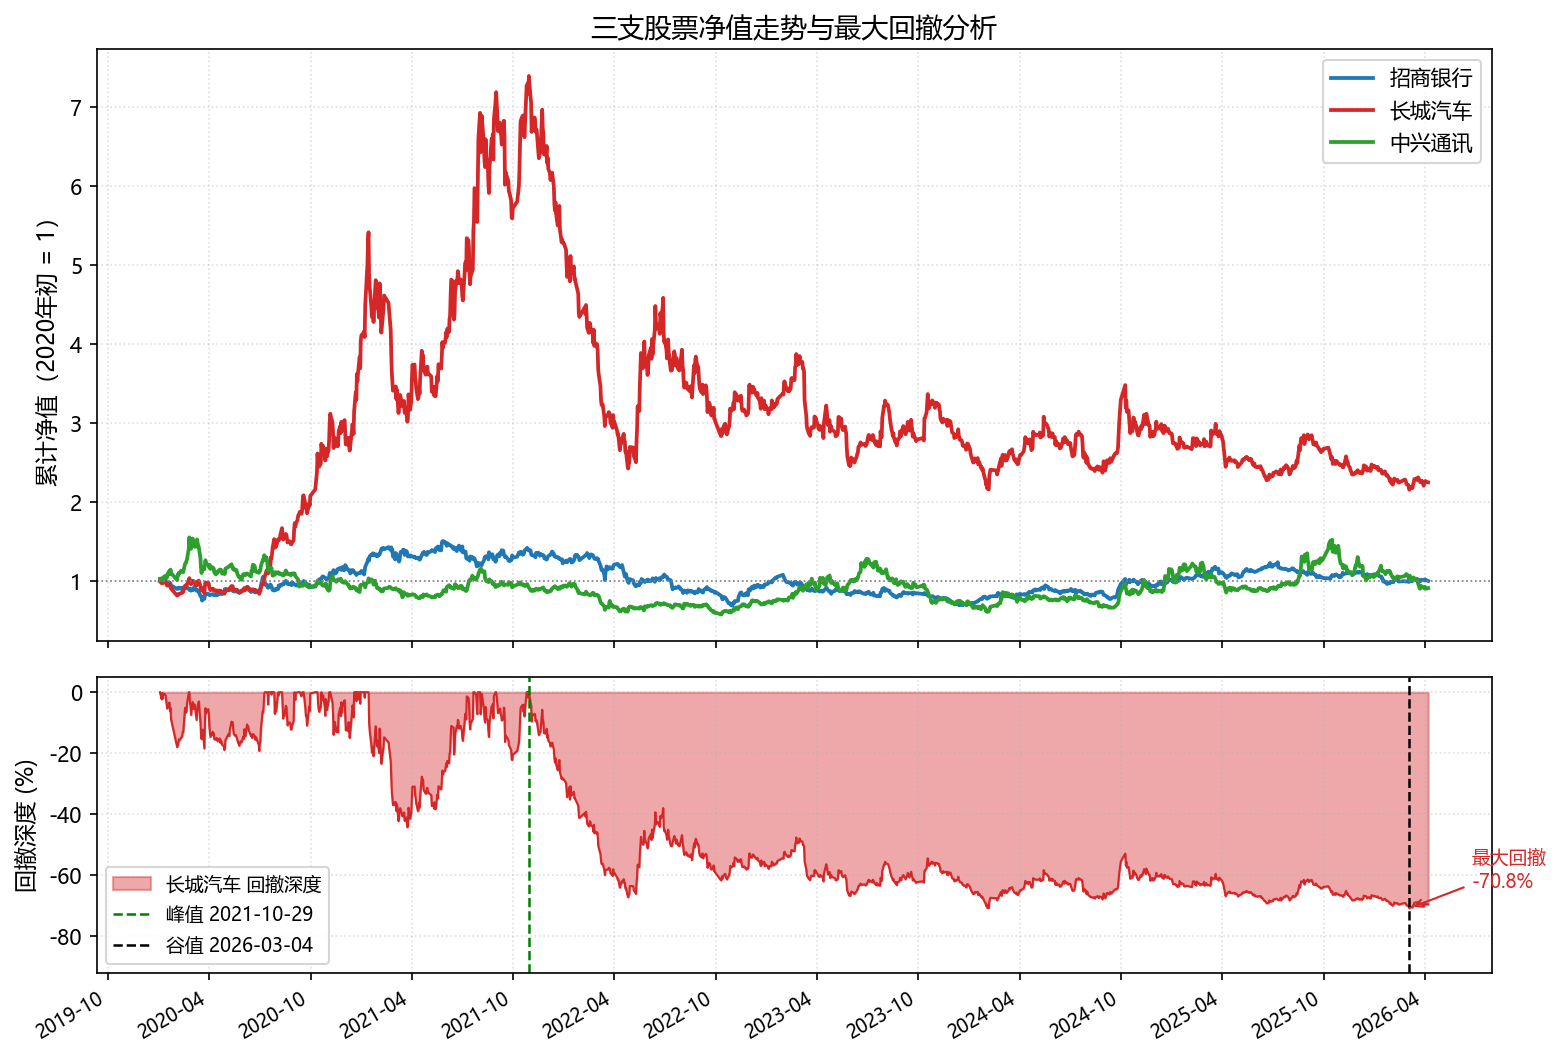

图片已保存：./figs/fig_portfolio_06_drawdown.png


In [25]:
# ------------------------------------------------------------------
# 绘图：净值走势 + 最大回撤深度图
# ------------------------------------------------------------------

# 找最大回撤最大的股票（用于第二子图）
mdd_values = {name: float(risk_df.loc[name, '最大回撤 (%)']) for name in names}
worst_name = min(mdd_values, key=lambda k: mdd_values[k])  # 最大回撤最负

# 计算各股票累计净值和回撤序列
nav_dict = {}
dd_dict  = {}
for name in names:
    r = ret_aligned[name]
    nav = np.exp(r.cumsum())
    nav_dict[name] = nav
    peak  = nav.cummax()
    dd_dict[name]  = (nav - peak) / peak * 100  # 回撤深度（%）

colors = ['#1f77b4', '#d62728', '#2ca02c']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8),
                                gridspec_kw={'height_ratios': [2, 1]},
                                sharex=True)
fig.subplots_adjust(hspace=0.08)

# ---- 子图1：累计净值 ----
for name, color in zip(names, colors):
    nav = nav_dict[name]
    ax1.plot(nav.index, nav, color=color, lw=1.8, label=name)

ax1.axhline(1, color='gray', lw=0.8, ls=':')
ax1.set_ylabel('累计净值（2020年初 = 1）', fontsize=11)
ax1.set_title('三支股票净值走势与最大回撤分析', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(linestyle=':', alpha=0.4)

# ---- 子图2：最大回撤股票的回撤深度图 ----
dd = dd_dict[worst_name]
ax2.fill_between(dd.index, dd, 0, color='#d62728', alpha=0.4, label=f'{worst_name} 回撤深度')
ax2.plot(dd.index, dd, color='#d62728', lw=1)

# 标注最大回撤的峰谷
peak_d  = pd.Timestamp(risk_df.loc[worst_name, '回撤峰值日'])
trough_d= pd.Timestamp(risk_df.loc[worst_name, '回撤谷值日'])
mdd_val = float(risk_df.loc[worst_name, '最大回撤 (%)'])

ax2.axvline(peak_d,   color='green', lw=1.2, ls='--', label=f'峰值 {peak_d.date()}')
ax2.axvline(trough_d, color='black', lw=1.2, ls='--', label=f'谷值 {trough_d.date()}')
ax2.annotate(f'最大回撤\n{mdd_val:.1f}%',
             (trough_d, mdd_val),
             xytext=(30, 10), textcoords='offset points',
             fontsize=9, color='#d62728',
             arrowprops=dict(arrowstyle='->', color='#d62728'))

ax2.set_ylabel('回撤深度 (%)', fontsize=11)
ax2.set_ylim(min(mdd_val * 1.3, -5), 5)
ax2.legend(fontsize=9, loc='lower left')
ax2.grid(linestyle=':', alpha=0.4)

# x 轴格式
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right', fontsize=9)

plt.savefig('./figs/fig_portfolio_06_drawdown.png')
plt.show()
print('图片已保存：./figs/fig_portfolio_06_drawdown.png')

## 全章图片清单

运行以上所有单元格后，`./figs/` 目录下应生成以下文件：

| 文件名 | 对应章节 | 内容 |
|--------|---------|------|
| `fig_portfolio_01_returns.png` | §1.1 | 三支股票日对数收益率时序图 |
| `fig_portfolio_02_diversification.png` | §1.2 | 不同相关系数下的风险-权重关系 |
| `fig_portfolio_03_n_assets.png` | §1.2 | 分散化效益随资产数量的递减 |
| `fig_portfolio_04_frontier.png` | §1.3 | 可行集、有效前沿与资本市场线 |
| `fig_portfolio_05_sml.png` | §1.4 | 证券市场线与个股 α、β |
| `fig_portfolio_06_drawdown.png` | §1.5 | 净值走势与最大回撤深度图 |